# 核心组件Model I/O

Model I/O是LangChain的核心组件，它主要用于和大语言模型LLM进行交互，包括三个部分：

1. 提示词模版输入 Prompt Template
2. 模型调用 Model Invocation
3. 输出解析 Output Parsing

针对每个环节，LangChain都提供了模版和工具，用于快捷的调用各种语言模型的接口。

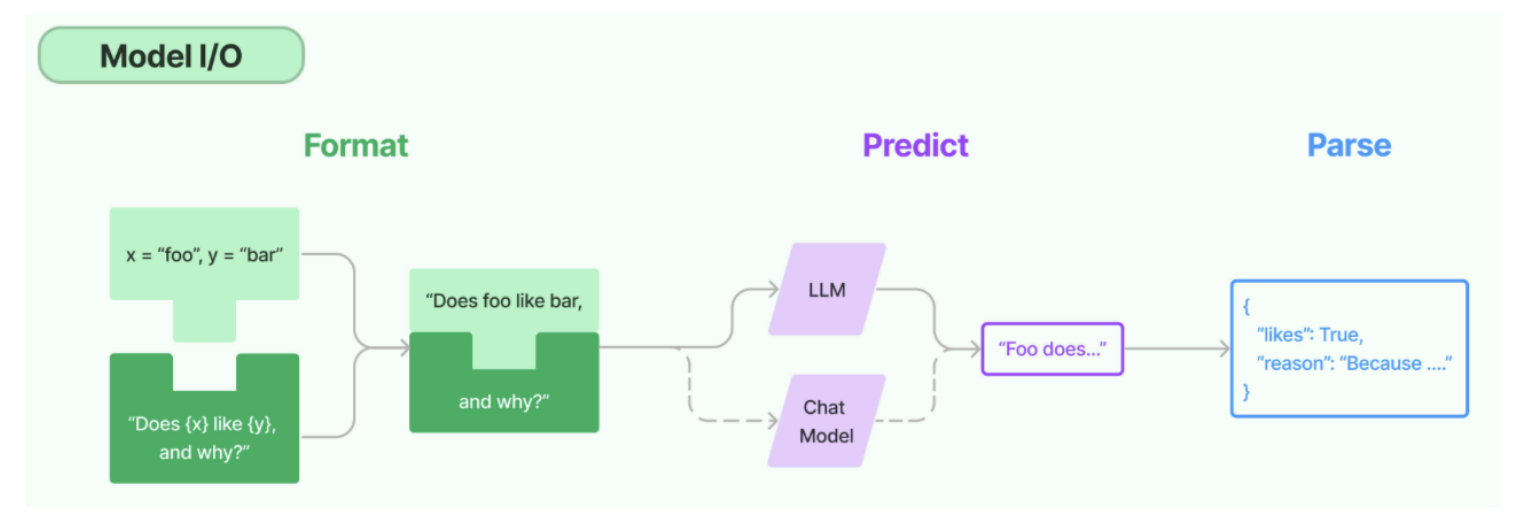

Tips: [大模型排名榜单 Leaderboard Overview](https://arena.ai/leaderboard)

## 模型调用流程

以最常见的对话模型调用为例，它主要包括以下几个步骤：

1. 导入对话模型类 ChatOpenAI
2. 实例化对话模型对象，传入核心参数
   - model_name：模型名称
   - base_url：模型接口地址
   - api_key：模型接口密钥
   - temperature：模型温度参数，控制输出的随机性
   - max_tokens：模型最大输出token数
   - max_retries：模型调用最大重试次数
   - timeout：模型调用超时时间
3. 创建消息列表List[BaseMessage]或者PromptValue
4. 调用模型对象的`invoke`方法，传入提示词或者消息列表
5. 解析模型返回的结果

## 模块对话Message

和AI大模型对话的消息格式支持三种类型：

1. PromptValue 文本提示 字符串形式 
2. 消息列表List[BaseMessage] 包含多个消息的列表
   - HumanMessage 人类消息 通常是用户输入的消息
   - AIMessage 助手消息 通常是模型生成的消息
   - SystemMessage 系统消息 用于设置模型行为的指令
   - FunctionMessage 函数消息 用于调用外部函数的消息
   - ToolMessage 工具消息 用于返回工具调用的结果
   - ChatMessage 聊天消息 用于存储任意类型的消息   
3. 消息列表List[BaseMessage] 包含多个消息对象的列表
   - role：消息角色 通常是用户或助手
   - content：消息内容 字符串形式


## init_chat_model

init_chat_model是langchain的chat_models库中提供的用于初始化对话模型的函数，它通过传入模型名称、接口地址、密钥等参数，返回一个对话模型对象。

在底层，它会根据传入的参数model——provider，创建一个对应厂商的对话模型实例，并对其进行配置。


In [1]:
from langchain_core.chat_models import (init_chat_model)
from langchain_deepseek import DeepseekChatModel

model = init_chat_model({
    'model_provider': 'openai',
    'model_name': 'gpt-3.5-turbo',
})


ModuleNotFoundError: No module named 'langchain'

上面的代码在内部会创建一个ChatOpenAI的实例对象，它会根据传入的参数，配置OpenAI的API接口地址、密钥等信息。并返回一个对话模型对象。

如果传入的是`deepseek`的模型，它会创建一个`ChatDeepseek`的实例对象。

如代码所示：

In [2]:
# 简单调用LangChain
import dotenv;
import os;
from langchain_openai import ChatOpenAI;
from langchain_core.messages import SystemMessage, HumanMessage;

dotenv.load_dotenv();

OPENAI_API_KEY= os.getenv('OPENAI_API_KEY');
MODEL_NAME = os.getenv('MODEL_NAME')
BASE_URL = os.getenv('BASE_URL')


model = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=1024,
)

messages = [
    SystemMessage(content="我是人工智能助手，我叫小智"),
    HumanMessage(content="你好，我是小明，很高兴认识你")
]

response = model.invoke(messages)
print(response.content)


你好小明！很高兴认识你！我是小智，一个AI助手。希望我们能成为好朋友，有什么我可以帮助你的吗？或者你想聊聊什么话题呢？


### 区分对话模型和非对话模型

1. 对话模型（Chat Model）
   比如在Langchain中通过`ChatOpenAI`类可以生成一个对话模型对象，它可以接收用户的输入，根据模型的训练，生成一个回复。其底层是调用了OpenAI的`/chat/completions`接口。

2. 非对话模型（Non-Chat Model）
   比如在Langchain中通过`OpenAI`类可以生成一个非对话模型对象，它可以接收用户的输入，根据模型的训练，生成一个回复。其底层是调用了OpenAI的`/completions`接口。

## 调用模型方法

### 非流式输出
在用户提问之后，系统在静默数秒之后一次性返回模型生成的结果，常见的方法如下：

- invoke() 方法 同步调用模型
- batch() 方法 同步批量调用模型
- ainvoke() 方法 异步调用模型
- abatch() 方法 异步批量调用模型

### 流式输出
在用户提问之后，系统会以流式的方式返回模型生成的结果，常见的方法如下：

- stream() 方法 同步流式调用模型
- astream() 方法 异步流式调用模型

In [ ]:

# 流式输出
model = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=2048,
)

messages = [
    SystemMessage(content="你是一个古典诗歌专家"),
    HumanMessage(content="你好，我是小明，请帮我写一首关于春天的古典诗歌")
]

responseIterator = model.stream(messages)
for chunk in responseIterator:
    # 打印流式输出的内容
    # end='' 表示不换行
    # flush=True 刷新缓冲区以即时显示内容
    print(chunk.content, end='',flush=True)


### 批量调用
通过batch方式可以批量调用模型，因此使用batch方法对于IO密集型任务可以显著提高调用效率。

它内部默认是没有依赖底层API的原生批量接口，而是通过线程池并行执行多个invoke方法，每个线程处理一个输入样本从而实现的。

但是如果模型底层API本身支持批量调用接口，那么可以通过设置`use_batch=True`来启用原生批量调用，或者子类可以重写batch方法来实现自定义的批量调用逻辑。

In [ ]:
model = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=2048,
)

messages = [
   [
     SystemMessage(content="你是一个古典诗歌专家"),
     HumanMessage(content="你好，我是小明，请帮我写一首关于春天的古典诗歌")
   ],
   [
     SystemMessage(content="你是一个古典诗歌专家"),
     HumanMessage(content="你好，我是小红，请帮我写一首关于夏天的古典诗歌")
   ],
   [
     SystemMessage(content="你是一个古典诗歌专家"),
     HumanMessage(content="你好，我是小刚，请帮我写一首关于秋天的古典诗歌")
   ],
]

response = model.batch(messages)
# 返回多个response
for chunk in response:
    print(chunk.content)


### 模型异步调用

模型的调用还可以支持异步调用，通过`await`关键字可以实现非阻塞的调用，提高系统的并发性能。
允许程序在等待模型响应的同时，继续执行其他任务，而不是阻塞在等待模型响应的地方。
这在处理IO密集型任务时特别有用比如（HTTP网络请求、文件读写）
但是不适用CPU密集型的任务，因为CPU密集型的计算任务是同步执行的，不会释放CPU资源，从而导致任务的阻塞。

Langchain 提供了异步调用的接口，通过`ainvoke`方法、`astream`方法、`abatch`方法可以实现异步调用。


In [ ]:
import asyncio;
import os;
import time;
import dotenv;
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=1024,
)

messages = [
    [
        {"role": "system", "content": "你是一位诗人"},
        {"role": "user", "content": "写一首关于春天的诗"},
    ],
    [
        {"role": "system", "content": "你是一位诗人"},
        {"role": "user", "content": "写一首关于夏天的诗"},
    ],

    [
        {"role": "system", "content": "你是一位诗人"},
        {"role": "user", "content": "写一首关于秋天的诗"},
    ]
]

# 异步调用LangChain方法
async def invokeLLM(messages: list):
    tasks = [];
    for message in messages:
        # ainvoke方法返回一个异步任务 ，需要使用await关键字等待任务完成
        task = model.ainvoke(message);
        tasks.append(task);

    # 类似js中的Promise.all方法，等待所有任务完成
    responses = await asyncio.gather(*tasks);

    return responses;
beginTime = time.time();
# asyncResponse = asyncio.run(invokeLLM(messages)) 在Jupyter Notebook中不能使用，会报错
asyncResponse = await invokeLLM(messages); # 直接使用await关键字 
endTime = time.time();
print(f'异步调用耗时: {endTime - beginTime}')
for chunk in asyncResponse:
    print(chunk.content)


### 异步调用和批量调用的区别

首先我们得先理解两个概念：
1. CPU密集型任务
2. IO密集型任务

CPU密集型任务指的是需要占用CPU资源进行计算的任务，比如进行复杂的数学计算、加密解密、数据压缩等。这些任务需要CPU快速地进行计算，并且在计算的过程中一直大量的消耗CPU的资源，CPU的使用率持续保持很高，几乎没有空闲的时间去执行其他任务，因此如果在CPU密集型任务中使用异步调用，就会导致任务的阻塞，从而影响系统的并发性能。

IO密集型任务指的是需要进行IO操作的任务，比如读写文件、数据库查询、网络请求等。这些任务需要等待IO操作完成，而在等待的过程中，CPU可以空闲下来执行其他任务，因此如果在IO密集型任务中使用异步调用，就可以充分利用CPU的空闲时间，提高系统的并发性能。

CPU密集型任务和IO密集型任务都有不同的方案来支持并发策略：
1. 对于CPU密集型任务，可以使用多进程来并发执行任务，利用多核CPU的硬件配置，提高系统的并发性能。

2. 对于IO密集型任务，由于其IO操作耗时较长，但是CPU大多数时间比较空闲，因此可以使用以下两个思路来处理并行任务。
   - 异步调用：等待I/O操作的过程中执行其他任务，等任务返回结果后，再继续执行后续的代码。
   - 多线程：在等待I/O操作的过程中，使用多线程来执行其他任务，从而充分利用CPU的空闲时间，提高系统的并发性能。

对于LangChain而言：
- 批量调用模型：通过batch方法去批量调用模型，本质是使用多线程去调用模型提高并发性能。
- 异步调用模型：通过ainvoke异步方法去调用模型，本质只有单线程在运行，但是可以在等待模型返回结果的同时，继续执行其他代码。

因此可以看出异步调用的优势在于可以在等待模型返回结果的同时，继续执行其他代码，并且可以减少线程的资源浪费；而批量调用则是并行多线程调用模型，效率更高，但比较消耗线程资源。


## 使用Ollama本地模型部署并通过LangChain调用

1. 安装Ollama
2. 下载模型
3. 本地启动模型
   
    ```bash
    ollama run qwen3.5:0.8b
    ```
4. 使用langchain_ollama提供的ChatOllama类调用模型

In [ ]:
from langchain_ollama import ChatOllama;
import dotenv

dotenv.load_dotenv()

ollama_model = ChatOllama(
    model=os.getenv('OLLAMA_MODEL_NAME'),
    base_url=os.getenv('OLLAMA_BASE_URL'),
)

response = ollama_model.invoke('你好,请你介绍下自己呢？')
print(response.content)


## 修改DEBUG日志等级抓包

默认情况下，Langchain的日志等级是INFO，这意味着只有INFO及以上级别的日志会被打印出来。如果我们想抓包查看更详细的日志，我们可以将日志等级修改为DEBUG。

如代码所示：
```python
import logging

logging.basicConfig(level=logging.DEBUG，format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
```

我们来运行一个简单的示例，看看DEBUG日志等级下的输出：

In [ ]:
from langchain_openai import ChatOpenAI
import logging;

# logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

model = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=2048,
)

model.invoke('你好')


## Prompt Template

### 什么是Prompt Template（提示词模版）
Prompt Template本质上就是一个字符串模版，它可以根据用户的输入，动态地生成一个提示词。
### 构建LangChain中的PromptTemplate模版实例
LangChain官方提供了`PromptTemplate`类，它可以根据用户的输入，动态地生成一个提示词。

1. 基于PromptTemplate类构建Prompt Template实例
2. 使用PromptTemplate类静态方法from_template方法生成template实例
3. 通过format方法格式化Prompt Template实例为字符串
4. 或通过invoke方法格式化Prompt Template实例为StringPromptValue类，然后再进一步调用toString方法获取字符串

In [ ]:
# 方案1:构建Prompt Template实例，然后调用模版的format方法生成提示词

from langchain_core.prompts import PromptTemplate;

template = PromptTemplate(
    template="请查询NBA{team}队最近{number}场比赛的结果",
    input_variables=['team', 'number'],
    partial_variables={'number': 3}, # 部分变量，number默认值为3 可省略
)

promptLakers = template.format(team='湖人')
print(promptLakers,type(promptLakers))

promptHeat = template.format(team='热火', number=5)
print(promptHeat)

promptLakers = template.invoke({'team': '湖人'})
print(promptLakers.text,type(promptLakers))

promptHeat = template.invoke({'team': '热火', 'number': 5})
print(promptHeat.to_string())


In [ ]:
# 方案2: 使用PromptTemplate类静态方法from_template方法生成提示词

from langchain_core.prompts import PromptTemplate;

template = PromptTemplate.from_template(
    "请查询NBA{team}队最近{number}场比赛的结果"
).partial(number=3) # 部分变量，number默认值为3


promptLakers = template.format(team='湖人')
print(promptLakers)

promptHeat = template.format(team='热火', number=4)
print(promptHeat)



### 构建ChatPromptTemplate实例并调用（聊天提示词模版）
ChatPromptTemplate是创建聊天消息列表的提示模板。
相较于普通 PromptTemplate更适合处理多角色、多轮次的对话场景。

1. 通过ChatPromptTemplate类的构造函数构建实例
2. 通过from_messages类方法构建实例

### 如何调用ChatPromptTemplate

调用模版生成聊天提示词：

1. invoke方法
2. format_messages方法

In [ ]:
# Dict格式 类型为List[Dict(role,content)]
template = ChatPromptTemplate(
  [
    {'role': 'system', 'content': '你是一个专业的翻译'},
    {'role': 'human', 'content': '{input}'},
    {'role': 'ai', 'content': '翻译结果：{output}'},
    {'role': 'human', 'content': '请继续翻译下一个句子{sentence}'},
    {'role': 'ai', 'content': '翻译结果：{outputSentence}'},
  ]
)

# 通过format_messages方法生成提示词
chatPrompt = template.format_messages(input='你好', output='Hello', sentence='很高兴认识你', outputSentence='I am glad to meet you')

print(chatPrompt)
for chunk in chatPrompt:
    print(chunk.type + ': ' + chunk.content + '\n')


### 消息占位符

当我们希望在将提示词模版格式化为提示词的时候，可以在已有的模版中动态的插入消息列表。
比如一个AI Agent可以暂存中间步骤，此时就需要消息占位符MessagePlaceholder。

1. 在构建模版的时候指定插槽名称和变量
2. 在格式化提示词的时候，通过插槽名称插入消息列表

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

template = ChatPromptTemplate.from_messages(

    [

        ("system", "你是一个助手。"),

        ("placeholder", "{conversation}"),

        # 等同于 MessagesPlaceholder(variable_name="conversation", optional=True)

    ]

)

prompt = template.format_messages(

    conversation=[

        ("human", "你好！"),

        ("ai", "想让我帮你做些什么？"),

        ("human", "能帮我做一个冰淇凌吗？"),

        ("ai", "不能"),

    ]

)

print(prompt)


### 多模态提示词

可以使用提示词模版来格式化多模态输入，比如图片链接

In [ ]:
import os;
from langchain_core.prompts import ChatPromptTemplate;
from langchain_openai import ChatOpenAI;
import dotenv;

dotenv.load_dotenv();

llm = ChatOpenAI(
    model=os.environ['MULTIMODAL_MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=1024,
)

template = ChatPromptTemplate.from_messages([
    ('system','用中文描述这个图像的内容'),
    ('human','{image_url}')
])

prompt = template.format_messages(
    image_url='https://img2.baidu.com/it/u=2976763563,2523722948&fm=253&app=138&f=JPEG?w=800&h=1200'
)

response = llm.invoke(prompt)
print(response.content)


### 通过Json或者YAML文件配置提示词模版

可以将 prompt 保存为 JSON 或者 YAML 等格式的文件，通过读取指定路径的格式化文件，获取相应的 prompt。这样方便对 prompt 进行管理和维护。



In [3]:
from langchain_core.prompts import load_prompt

prompt = load_prompt('src/prompt/prompt.json')

print(prompt.format(name='张三', what='历史'))


请张三讲一个历史的故事


## Output Parser

语言模型返回的内容通常都是文本字符串，而实际 AI 应用开发过程中有时希望模型可以返回更直观、更格式化的内容，LangChain 提供了输出解析器（Output Parser）将模型输出解析为结构化数据。

有多种类型的输出解析器，常用的有 StrOutputParser（字符串解析器）与 JsonOutputParser（JSON解析器）。

### JsonOutputParser（JSON解析器）
1. 基于 pydantic 提供的Model构建schema
2. 基于 schema 定义 JsonOutputParser 实例
3. 基于 JsonOutputParser 实例的 方法 get_format_instructions 获取格式化指令（第一次使用）
4. 基于格式化指令构建 prompt
5. 调用大模型执行 prompt
6. 调用 JsonOutputParser 实例的 方法 parse 解析模型输出（第二次使用）


In [5]:
from pydantic import BaseModel,Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai.chat_models import ChatOpenAI
import os
import dotenv;

dotenv.load_dotenv()

# 1. 构建schema
class TeamResponse(BaseModel):
    team_name: str = Field(description = "球队名称")
    date: str = Field(description = "比赛日期")
    score:str = Field(description = "最终比分")
    desc: str = Field(description = "比赛总结")

# 2. 定义 JsonOutputParser 实例
outputParser = JsonOutputParser(
    pydantic_object = TeamResponse
)

outputPrompt = outputParser.get_format_instructions()

template = ChatPromptTemplate.from_messages([
    ("system", "{outputPrompt}"),
    ("human", "{input}")
])

prompt = template.invoke({
    "input": "你好,帮我介绍下热火队最近比赛的情况",
    "outputPrompt": outputPrompt
})

# 3. 构建大模型
llm = ChatOpenAI(
    model=os.environ['MODEL_NAME'],
    base_url=os.environ['BASE_URL'],
    api_key=os.environ['OPENAI_API_KEY'],
    temperature=0.5,
    max_tokens=2048,
)

response = llm.invoke(prompt)
print(response.content)
print(outputParser.invoke(response.content))


{
  "team_name": "迈阿密热火队",
  "date": "2023年4月15日",
  "score": "108-95",
  "desc": "热火队在本场比赛中展现了强大的团队配合和防守强度，最终以108比95击败对手。球队核心球员巴特勒贡献了28分和7个篮板，阿德巴约拿下22分和10个篮板的两双数据。全队三分球命中率高达38%，有效压制了对手的进攻节奏。这场比赛体现了热火队在季后赛争夺中的良好状态和竞技水平。"
}
{'team_name': '迈阿密热火队', 'date': '2023年4月15日', 'score': '108-95', 'desc': '热火队在本场比赛中展现了强大的团队配合和防守强度，最终以108比95击败对手。球队核心球员巴特勒贡献了28分和7个篮板，阿德巴约拿下22分和10个篮板的两双数据。全队三分球命中率高达38%，有效压制了对手的进攻节奏。这场比赛体现了热火队在季后赛争夺中的良好状态和竞技水平。'}


### StrOutputParser（字符串解析器）
1. 定义 StrOutputParser 实例
2. 调用 parse/invoke 方法解析模型输出
3. 返回解析后的字符串

In [ ]:
from langchain_core.output_parsers import StrOutputParser;

strOutputParser = StrOutputParser()

res = llm.invoke([
    {"role": "system", "content": "你好，你是一个专业的助手，你可以回答用户的问题。"},
    {"role": "user", "content": "请介绍电脑的好处"},
])

print(strOutputParser.invoke(res.content))


### StructuredOutputParser（结构化输出解析器）
1. 定义schema（支持python内置数据类型TypedDict、Pydantic、JsonSchema等）
2. 直接调用大模型自身的with_structured_output方法，传入schema
3. 调用大模型的invoke方法，传入消息
4. 解析模型输出，返回结构化数据

注意：with_structured_output 方法需要模型原生支持结构化输出 ，目前主要支持：

- OpenAI GPT-4 / GPT-3.5-turbo
- Anthropic Claude
- Google Gemini

In [ ]:
class TeamResponse(BaseModel):
    team_name: str = Field(description = "球队名称")
    date: str = Field(description = "比赛日期")
    score:str = Field(description = "最终比分")
    desc: str = Field(description = "比赛总结")

lm_with_structured_output = llm.with_structured_output(TeamResponse)

response = lm_with_structured_output.invoke([
    {"role": "system", "content": "你好，你是一个专业的助手，你可以回答用户的问题。并以json格式输出"},
    {"role": "user", "content": "请介绍火箭队最近的比赛"},
])

print(response.team_name)
